In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv("Salary_Data[1].csv")
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [4]:
df.shape

(6704, 6)

In [5]:
df.describe()

,Age,Years of Experience,Salary
count,6702.000000,6701.000000,6699.000000
mean,33.620859,8.094687,115326.964771
std,7.614633,6.059003,52786.183911
min,21.000000,0.000000,350.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,115000.000000
75%,38.000000,12.000000,160000.000000
max,62.000000,34.000000,250000.000000


In [6]:
df.isna().sum()

Age                    2
Gender                 2
Education Level        3
Job Title              2
Years of Experience    3
Salary                 5
dtype: int64

In [7]:
df=df.fillna(0)

In [8]:
df.isna().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

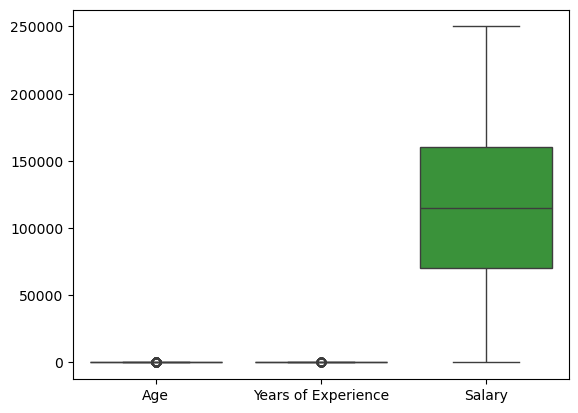

In [9]:
sns.boxplot(df)
plt.show()


In [10]:
Q1=df["Age"].quantile(0.25)
Q3=df["Age"].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df = df[(df["Age"] >= lower_bound) & (df["Age"] <= upper_bound)]

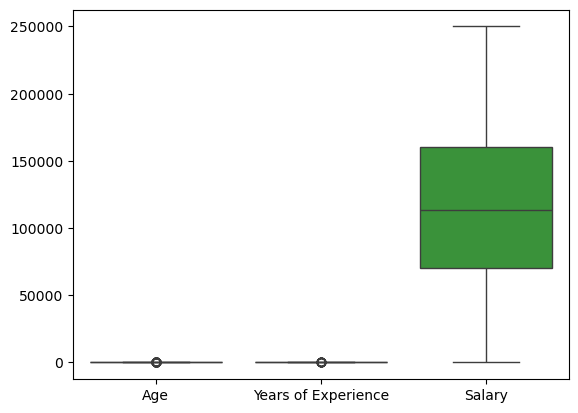

In [11]:
sns.boxplot(df)
plt.show()


In [12]:
Q1=df["Years of Experience"].quantile(0.25)
Q3=df["Years of Experience"].quantile(0.75)
IQR=Q3-Q1
lower_bound=Q1-1.5*IQR
upper_bound=Q3+1.5*IQR
df = df[(df["Years of Experience"] >= lower_bound) & (df["Years of Experience"] <= upper_bound)]

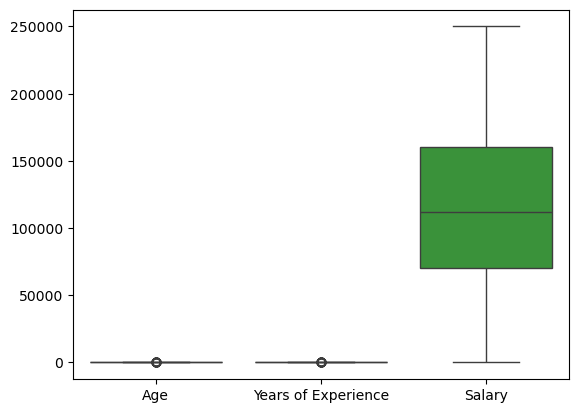

In [13]:
sns.boxplot(df)
plt.show()


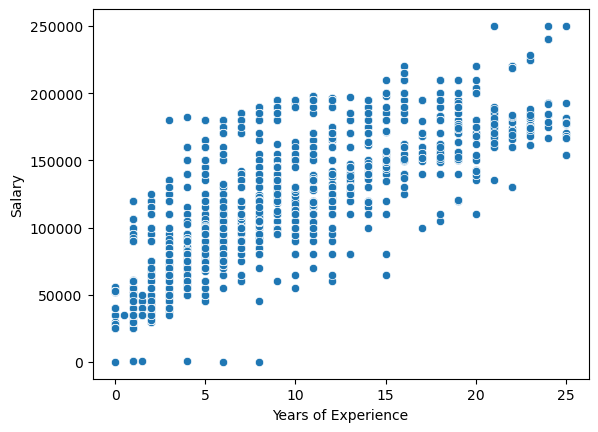

In [14]:
sns.scatterplot(x="Years of Experience", y="Salary", data=df)
plt.show()

In [15]:
df.isna().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

In [16]:
df.describe()

,Age,Years of Experience,Salary
count,6554.000000,6554.000000,6554.000000
mean,33.141898,7.743439,113573.387550
std,6.983358,5.580588,52150.708202
min,21.000000,0.000000,0.000000
25%,28.000000,3.000000,70000.000000
50%,32.000000,7.000000,111767.500000
75%,37.000000,11.000000,160000.000000
max,53.000000,25.000000,250000.000000


In [17]:
df.head(10)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0
5,29.0,Male,Bachelor's,Marketing Analyst,2.0,55000.0
6,42.0,Female,Master's,Product Manager,12.0,120000.0
7,31.0,Male,Bachelor's,Sales Manager,4.0,80000.0
8,26.0,Female,Bachelor's,Marketing Coordinator,1.0,45000.0
9,38.0,Male,PhD,Senior Scientist,10.0,110000.0


In [18]:

df["Education Level"].unique()

array(["Bachelor's", "Master's", 'PhD', "Bachelor's Degree",
       "Master's Degree", 0, 'High School', 'phD'], dtype=object)

In [19]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

cols = ["Gender", "Education Level"]

for col in cols:
    df[col] = LabelEncoder().fit_transform(df[col].astype(str))

df[cols] = MinMaxScaler().fit_transform(df[cols])

df

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,0.5,0.142857,Software Engineer,5.0,90000.0
1,28.0,0.0,0.571429,Data Analyst,3.0,65000.0
2,45.0,0.5,0.857143,Senior Manager,15.0,150000.0
3,36.0,0.0,0.142857,Sales Associate,7.0,60000.0
4,52.0,0.5,0.571429,Director,20.0,200000.0
...,...,...,...,...,...,...
6699,49.0,0.0,0.857143,Director of Marketing,20.0,200000.0
6700,32.0,0.5,0.428571,Sales Associate,3.0,50000.0
6701,30.0,0.0,0.285714,Financial Manager,4.0,55000.0
6702,46.0,0.5,0.714286,Marketing Manager,14.0,140000.0


In [20]:
x=df.drop(columns=["Salary","Job Title"])
y=df["Salary"]


In [21]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)


In [22]:
from sklearn.linear_model import LinearRegression
model=LinearRegression()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)

In [23]:
from sklearn.metrics import mean_absolute_error
mae=mean_absolute_error(y_test,y_pred)
print(mae)

22222.688396559875


In [24]:
from sklearn.metrics import r2_score
print(r2_score(y_test, y_pred))

0.7184500449792515
